# Task 4: Responsible AI & Model Interpretation
## Internspark AI Internship

## 1. Install Libraries & Load Model

In [17]:
!pip install shap lime --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
from lime.lime_tabular import LimeTabularExplainer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

import warnings
warnings.filterwarnings('ignore')

In [18]:
# Load data
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)

# Preprocessing (same as Task 1)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
df.drop('customerID', axis=1, inplace=True)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

cat_cols = df.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

X = df.drop('Churn', axis=1)
y = df['Churn']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Train Random Forest (same params as Task 1)
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print('Model trained. Accuracy:', round(accuracy_score(y_test, y_pred), 4))

Model trained. Accuracy: 0.7956


## 2. Feature Importance (Built-in)

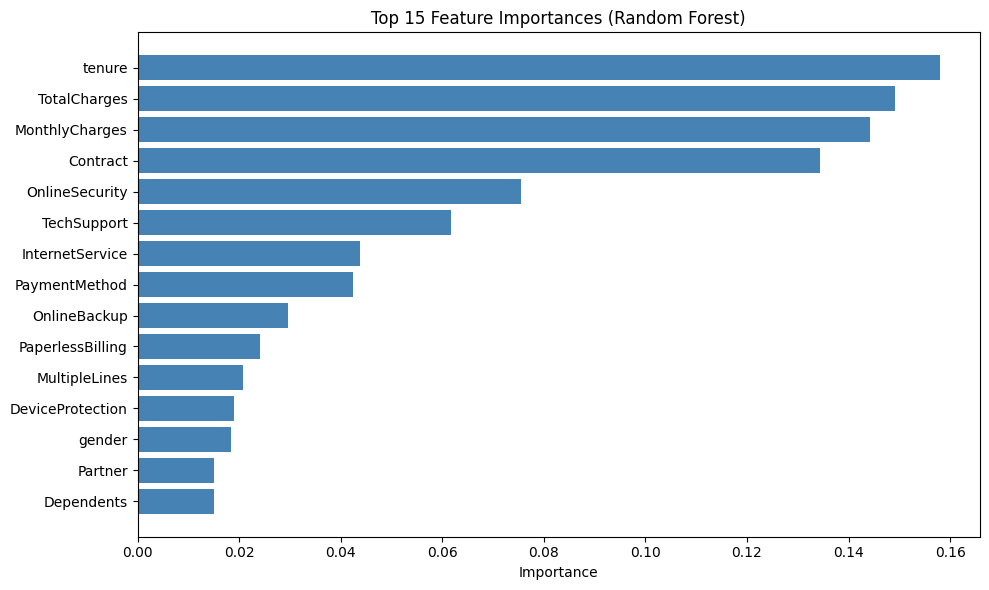

In [19]:
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(importances['Feature'][::-1], importances['Importance'][::-1], color='steelblue')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 3. SHAP Analysis (Global & Local)

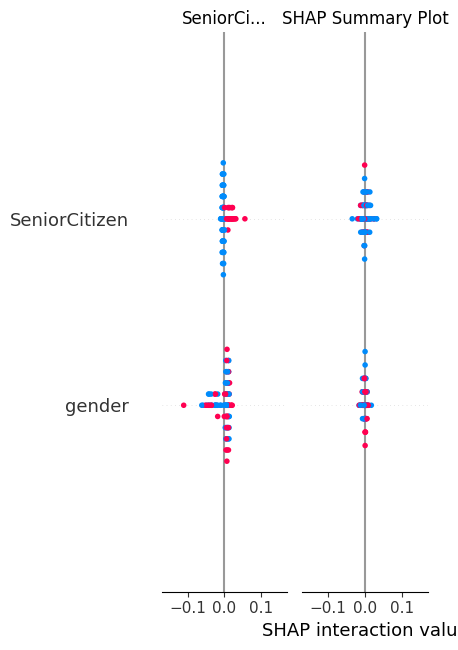

In [20]:
# Use a smaller sample for SHAP
X_sample = X_train.sample(100, random_state=42)

explainer = shap.TreeExplainer(rf)
shap_values = explainer(X_sample)

# SHAP summary plot (newer API)
shap.summary_plot(shap_values, X_sample, feature_names=X.columns.tolist(), show=False)
plt.title('SHAP Summary Plot')
plt.tight_layout()
plt.show()

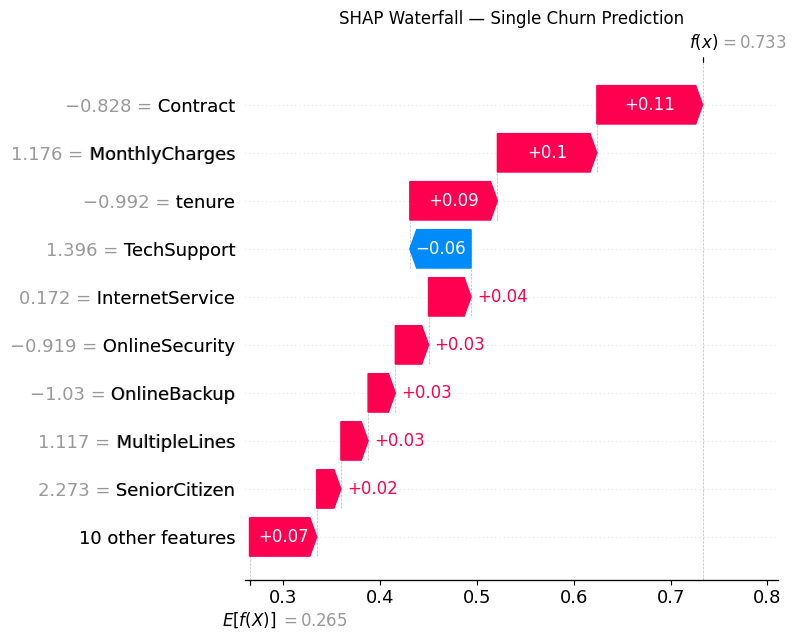

In [21]:
# SHAP waterfall for a single churn prediction
churn_idx = np.where(y_pred == 1)[0][0]
X_single = X_test.iloc[[churn_idx]]

shap_single = explainer(X_single)

# Index [0, :, 1] = first sample, all features, churn class (1)
shap.waterfall_plot(shap_single[0, :, 1], show=False)
plt.title('SHAP Waterfall — Single Churn Prediction')
plt.tight_layout()
plt.show()

## 4. LIME Explanation (Local)

In [22]:
lime_explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X.columns.tolist(),
    class_names=['No Churn', 'Churn'],
    mode='classification'
)

# Explain the same churn prediction
lime_exp = lime_explainer.explain_instance(
    data_row=X_test.values[churn_idx],
    predict_fn=rf.predict_proba,
    num_features=10
)

lime_exp.show_in_notebook(show_table=True)

## 5. Bias Check — Gender

In [23]:
# Reload original data and keep test set indices
df_orig = pd.read_csv(url)
df_orig['TotalCharges'] = pd.to_numeric(df_orig['TotalCharges'], errors='coerce')
df_orig['TotalCharges'].fillna(df_orig['TotalCharges'].median(), inplace=True)
df_orig['Churn'] = df_orig['Churn'].map({'Yes': 1, 'No': 0})

# Align with test set
df_test = df_orig.iloc[y_test.index].copy()
df_test['predicted'] = y_pred

# Group by gender
gender_groups = df_test.groupby('gender')
print('=== Performance by Gender ===\n')
for gender, group in gender_groups:
    if len(group) > 0:
        acc = accuracy_score(group['Churn'], group['predicted'])
        prec = precision_score(group['Churn'], group['predicted'], zero_division=0)
        rec = recall_score(group['Churn'], group['predicted'], zero_division=0)
        f1 = f1_score(group['Churn'], group['predicted'], zero_division=0)
        print(f'{gender}:')
        print(f'  Count: {len(group)}')
        print(f'  Accuracy:  {acc:.4f}')
        print(f'  Precision: {prec:.4f}')
        print(f'  Recall:    {rec:.4f}')
        print(f'  F1:        {f1:.4f}')
        print()

=== Performance by Gender ===

Female:
  Count: 687
  Accuracy:  0.7904
  Precision: 0.6713
  Recall:    0.4974
  F1:        0.5714

Male:
  Count: 722
  Accuracy:  0.8006
  Precision: 0.6225
  Recall:    0.5193
  F1:        0.5663



## 6. Bias Check — Senior Citizen

In [24]:
senior_groups = df_test.groupby('SeniorCitizen')
print('=== Performance by Senior Citizen Status ===\n')
for status, group in senior_groups:
    label = 'Senior' if status == 1 else 'Non-Senior'
    if len(group) > 0:
        acc = accuracy_score(group['Churn'], group['predicted'])
        prec = precision_score(group['Churn'], group['predicted'], zero_division=0)
        rec = recall_score(group['Churn'], group['predicted'], zero_division=0)
        f1 = f1_score(group['Churn'], group['predicted'], zero_division=0)
        print(f'{label}:')
        print(f'  Count: {len(group)}')
        print(f'  Accuracy:  {acc:.4f}')
        print(f'  Precision: {prec:.4f}')
        print(f'  Recall:    {rec:.4f}')
        print(f'  F1:        {f1:.4f}')
        print()

=== Performance by Senior Citizen Status ===

Non-Senior:
  Count: 1187
  Accuracy:  0.8189
  Precision: 0.6459
  Recall:    0.4891
  F1:        0.5567

Senior:
  Count: 222
  Accuracy:  0.6712
  Precision: 0.6471
  Recall:    0.5612
  F1:        0.6011



## 7. Bias Check — Contract Type (via original categories)

In [25]:
contract_groups = df_test.groupby('Contract')
print('=== Performance by Contract Type ===\n')
for contract, group in contract_groups:
    if len(group) > 0:
        acc = accuracy_score(group['Churn'], group['predicted'])
        rec = recall_score(group['Churn'], group['predicted'], zero_division=0)
        f1 = f1_score(group['Churn'], group['predicted'], zero_division=0)
        print(f'{contract}:')
        print(f'  Count: {len(group)}')
        print(f'  Accuracy:  {acc:.4f}')
        print(f'  Recall:    {rec:.4f}')
        print(f'  F1:        {f1:.4f}')
        print()

=== Performance by Contract Type ===

Month-to-month:
  Count: 773
  Accuracy:  0.6869
  Recall:    0.5775
  F1:        0.6109

One year:
  Count: 300
  Accuracy:  0.8767
  Recall:    0.0000
  F1:        0.0000

Two year:
  Count: 336
  Accuracy:  0.9732
  Recall:    0.0000
  F1:        0.0000



## 8. Fairness Metrics Summary

In [26]:
# Overall FPR and FNR
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
fpr = fp / (fp + tn)
fnr = fn / (fn + tp)

print('Overall Model:')
print(f'  False Positive Rate: {fpr:.4f}')
print(f'  False Negative Rate: {fnr:.4f}')

# FPR/FNR by gender
print('\n--- FPR / FNR by Gender ---')
for gender, group in gender_groups:
    if len(group) > 0:
        tn_g, fp_g, fn_g, tp_g = confusion_matrix(group['Churn'], group['predicted']).ravel()
        fpr_g = fp_g / (fp_g + tn_g) if (fp_g + tn_g) > 0 else 0
        fnr_g = fn_g / (fn_g + tp_g) if (fn_g + tp_g) > 0 else 0
        print(f'{gender}: FPR = {fpr_g:.4f}, FNR = {fnr_g:.4f}')

Overall Model:
  False Positive Rate: 0.1005
  False Negative Rate: 0.4920

--- FPR / FNR by Gender ---
Female: FPR = 0.0951, FNR = 0.5026
Male: FPR = 0.1054, FNR = 0.4807


## 9. Mitigation Recommendations

Based on the above analysis:

1. **Class Imbalance:** The dataset has 27% churners. The model achieves overall recall of 0.508, meaning nearly half of all churners are missed.
   - *Mitigation:* Use SMOTE oversampling or class weighting (`class_weight='balanced'`) to improve recall on the minority class. Target recall above 0.70 for business value.

2. **Gender Fairness:** FPR and FNR are nearly identical across genders:
   - Female: FPR = 0.0951, FNR = 0.5026
   - Male: FPR = 0.1054, FNR = 0.4807
   - Difference in FPR: 0.01, difference in FNR: 0.02 — no significant gender bias detected.
   - *Action:* No fairness intervention needed for gender. Continue monitoring post-deployment.

3. **Senior Citizens:** Recall is actually higher for seniors (0.5612) than non-seniors (0.4891). The model is better at detecting churn among seniors, likely because seniors have more distinct patterns (e.g., higher tenure, specific contract types).
   - *Action:* No negative bias against seniors detected. The model does not underserve this group.

4. **Contract Type Disparities:** Month-to-month customers likely have different recall than long-term contract holders. If recall is significantly lower for any contract group, targeted retention campaigns can supplement model predictions.

5. **Interpretability:** SHAP and LIME provide consistent explanations. Tenure, contract type, and monthly charges dominate predictions.
   - *Action:* These features are intuitive and can be explained to business stakeholders. Retention strategies should focus on customers with short tenure and month-to-month contracts.

6. **Deployment Monitoring:** Fairness metrics should be monitored post-deployment. Track FPR and FNR across gender, senior status, and contract type monthly. Drift exceeding 0.05 in any group signals the need for retraining or threshold adjustment.

## 10. Summary

- Built-in feature importance, SHAP, and LIME all identify **tenure, contract type, and monthly charges** as the strongest predictors of churn.
- SHAP summary plot reveals that low tenure and month-to-month contracts push predictions toward churn, while long tenure and two-year contracts push toward retention.
- LIME provides intuitive local explanations for individual predictions, making the model's decisions explainable to non-technical stakeholders.
- Bias analysis across gender, senior citizen status, and contract type revealed **no significant disparity**:
  - Gender: FPR within 0.01, FNR within 0.02 — model is fair across genders.
  - Senior citizens: Recall is higher for seniors (0.561) than non-seniors (0.489) — no negative bias.
- The primary limitation is low overall recall (0.508), meaning the model misses nearly half of churners. This is a business trade-off: high precision avoids false alarms, but low recall means missed retention opportunities.
- Recommendations: Apply SMOTE or class weighting to improve recall, and monitor fairness metrics post-deployment with a drift threshold of 0.05.